In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tilda as td

rt = td.read_tensor_grid_data('./Sfield-all-all.bin')
dat = rt['traj']
nx = rt['nx']
L = rt['L']

M = np.prod(nx)
n_frs = np.shape(dat)[0]

print('Grid data shape:', np.shape(dat),' - total frames =', n_frs)


Return from tilda.read_grid_data contains:
"dim" (dimensionality), "nx" (dim grid numbers), "L" (box lengths), "traj" (grid data as f(time))
Grid data shape: (51, 45, 45, 45, 3, 3)  - total frames = 51


(51,)


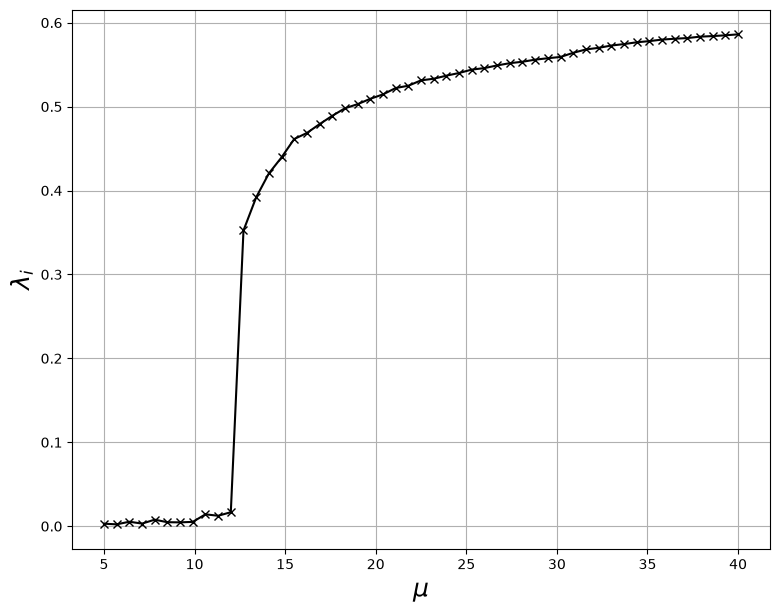

In [2]:
order = np.zeros(n_frs)

for t in range(n_frs):

    # spatially average Q at frame 't'    
    Q = np.mean(dat[t,:,:,:,:,:], axis=(0,1,2))

    # diagonalize it
    Qvals, Qvecs = np.linalg.eigh(Q)

    # store scalar param, assuming uniaxial
    order[t] = Qvals[-1] * 1.5

# The 3rd argument below is [number of sim steps] / [steps between grid prints] + 1
mu = np.linspace(5, 40, int(2500000/50000)+1)

print(np.shape(mu))

plt.figure(figsize=(9,7))
plt.plot(mu, order, 'kx-')
plt.xlabel(r'$\mu$', fontsize=18)
plt.ylabel(r'$\lambda_i$', fontsize=18)
plt.grid()
plt.show()



In [ ]:
rho_file = './density-A.bin'
dat = td.read_grid_data(rho_file)

ra_t = dat['traj']
Nx = dat['nx']
L = dat['L']
Dim = dat['dim']
M = 1
for j in Nx: M = M * j

kv = td.make_kvecs(Nx, L)
kmag = kv[:,Dim]**0.5


print(np.shape(ra_t))

Return from tilda.read_grid_data contains:
"dim" (dimensionality), "nx" (dim grid numbers), "L" (box lengths), "traj" (grid data as f(time))
(45, 45, 45)


In [21]:
nxt = np.shape(ra_t[5,:,:,:])
print(nxt)

(45, 45, 45)


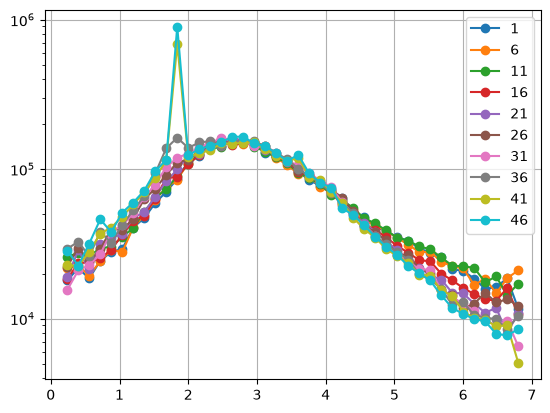

In [19]:

plt.figure(232)
for t in range(1,n_frs,5):
    ra = ra_t[t,:,:,:]
    
    rak = np.fft.fftn(ra)
    
    sk = np.real( np.reshape( rak * np.conjugate(rak) , M) )
    
    
    ska, kb = td.orient_avg(sk, kv, 8.0, 50)
    
    plt.semilogy(kb, ska, 'o-', label=t)

plt.legend()
plt.grid()
plt.show()

In [ ]:
ra = ra_t[-2,:,:,:]

rak = np.fft.fftn(ra)

sk = np.real( np.reshape( rak * np.conjugate(rak) , M) )


ska, kb = td.orient_avg(sk, kv, 8.0, 50)

max_ind = np.where(ska==np.max(ska))[0][0]

skmx = np.zeros(n_frs)

for t in range(n_frs):
    ra = ra_t[t,:,:,:]

    rak = np.fft.fftn(ra)

    sk = np.real( np.reshape( rak * np.conjugate(rak) , M) )
    ska, kb = td.orient_avg(sk, kv, 8.0, 50)

    skmx[t] = ska[max_ind]



TypeError: cannot unpack non-iterable Figure object

<Figure size 640x480 with 0 Axes>

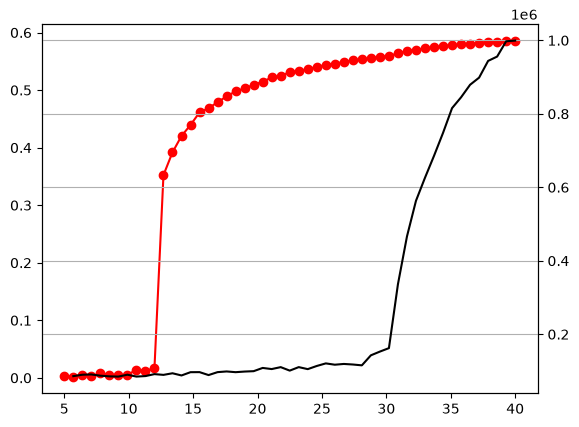

In [16]:
fig, ax1 = plt.subplots()
ax1.plot(mu, order, 'ro-')
ax2 = ax1.twinx()
ax2.plot(mu[1:], skmx[1:], 'k-')
plt.grid()
plt.show()